# Análisis de características de audio (Spotify Tracks Dataset)

## 0.1. Introducción

El objetivo de este proyecto es realizar un análisis exploratorio de datos (EDA) del dataset de Spotify Tracks, enfocándose en comprender las características de audio, las características de las pistas y los patrones que influyen en la popularidad y el engagement de las pistas en la plataforma.

Este es un **proyecto de análisis descriptivo** donde buscamos descubrir insights y patrones en las características musicales de miles de pistas.

## 0.2. Descripción del dataset

El dataset utilizado contiene información de pistas de Spotify con características de audio detalladas.

- Número de observaciones: ~114,000 pistas
- Unidad de análisis: 1 fila = 1 pista

El dataset incluye metadatos de pistas (nombre, artista, álbum) y métricas detalladas de características de audio calculadas por los algoritmos de análisis de audio de Spotify.

## 0.3. Características de audio

El dataset contiene las siguientes características de audio clave:

- **Acousticness (acústicamente)**: Medida de confianza de si la pista es acústica (0.0 - 1.0)
- **Danceability (danzabilidad)**: Idoneidad de una pista para bailar (0.0 - 1.0)
- **Energy (energía)**: Intensidad y nivel de actividad (0.0 - 1.0)
- **Instrumentalness (instrumentalidad)**: Probabilidad de que la pista sea instrumental (0.0 - 1.0)
- **Liveness (sonido en vivo)**: Presencia de audiencia en vivo (0.0 - 1.0)
- **Loudness (volumen)**: Volumen general en decibelios (dB)
- **Speechiness (hablabilidad)**: Presencia de palabras habladas (0.0 - 1.0)
- **Tempo**: Velocidad y ritmo en pulsaciones por minuto (BPM)
- **Valence (valencia)**: Positividad musical/alegría (0.0 - 1.0)
- **Popularity (popularidad)**: Puntuación de popularidad de Spotify (0 - 100)

## 0.4. Objetivos del proyecto

Los principales objetivos de este análisis son:

1. Realizar análisis exploratorio de datos (EDA) en el dataset de Spotify
2. Entender la distribución de las características de audio
3. Identificar patrones y correlaciones entre características de audio
4. Analizar la relación entre características de audio y popularidad de pistas
5. Descubrir patrones de agrupamiento en datos musicales
6. Visualizar tendencias e insights en el dataset

## 0.5. Estructura del proyecto

El análisis seguirá estas fases:

1. Carga y exploración inicial de datos
2. Limpieza y preparación de datos
3. Análisis Exploratorio de Datos (EDA)
4. Análisis estadístico y correlaciones
5. Visualización de patrones y tendencias
6. Insights y conclusiones

---

# 1. Carga y exploración de datos

## 1.1 Importación de librerías requeridas

Importamos las librerías necesarias para la manipulación y análisis de datos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración básica
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1.2. Carga del dataset

El dataset se carga desde un archivo CSV descargado de Kaggle. El archivo debe colocarse en la carpeta `data/`.

In [23]:
df = pd.read_csv("../data/spotify-tracks.csv")

## 1.3. Exploración inicial de datos

Examinamos las primeras filas del dataset para entender su estructura.

In [24]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Dimensiones del dataset e información básica

In [ ]:
print(f"Dimensiones del dataset: {df.shape}")
print(f"\nNúmero de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Dataset shape: (114000, 20)

Number of rows: 114000
Number of columns: 20


### Tipos de datos y valores faltantes

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [27]:
df.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

### Resumen estadístico

In [28]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


---

# 2. Análisis exploratorio de datos (EDA)

## 2.1. Distribución de características de audio

Analizamos la distribución de las principales características de audio para entender sus características.

In [ ]:
# Seleccionar columnas numéricas para análisis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Columnas numéricas: {numeric_cols}")

Numeric columns: ['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


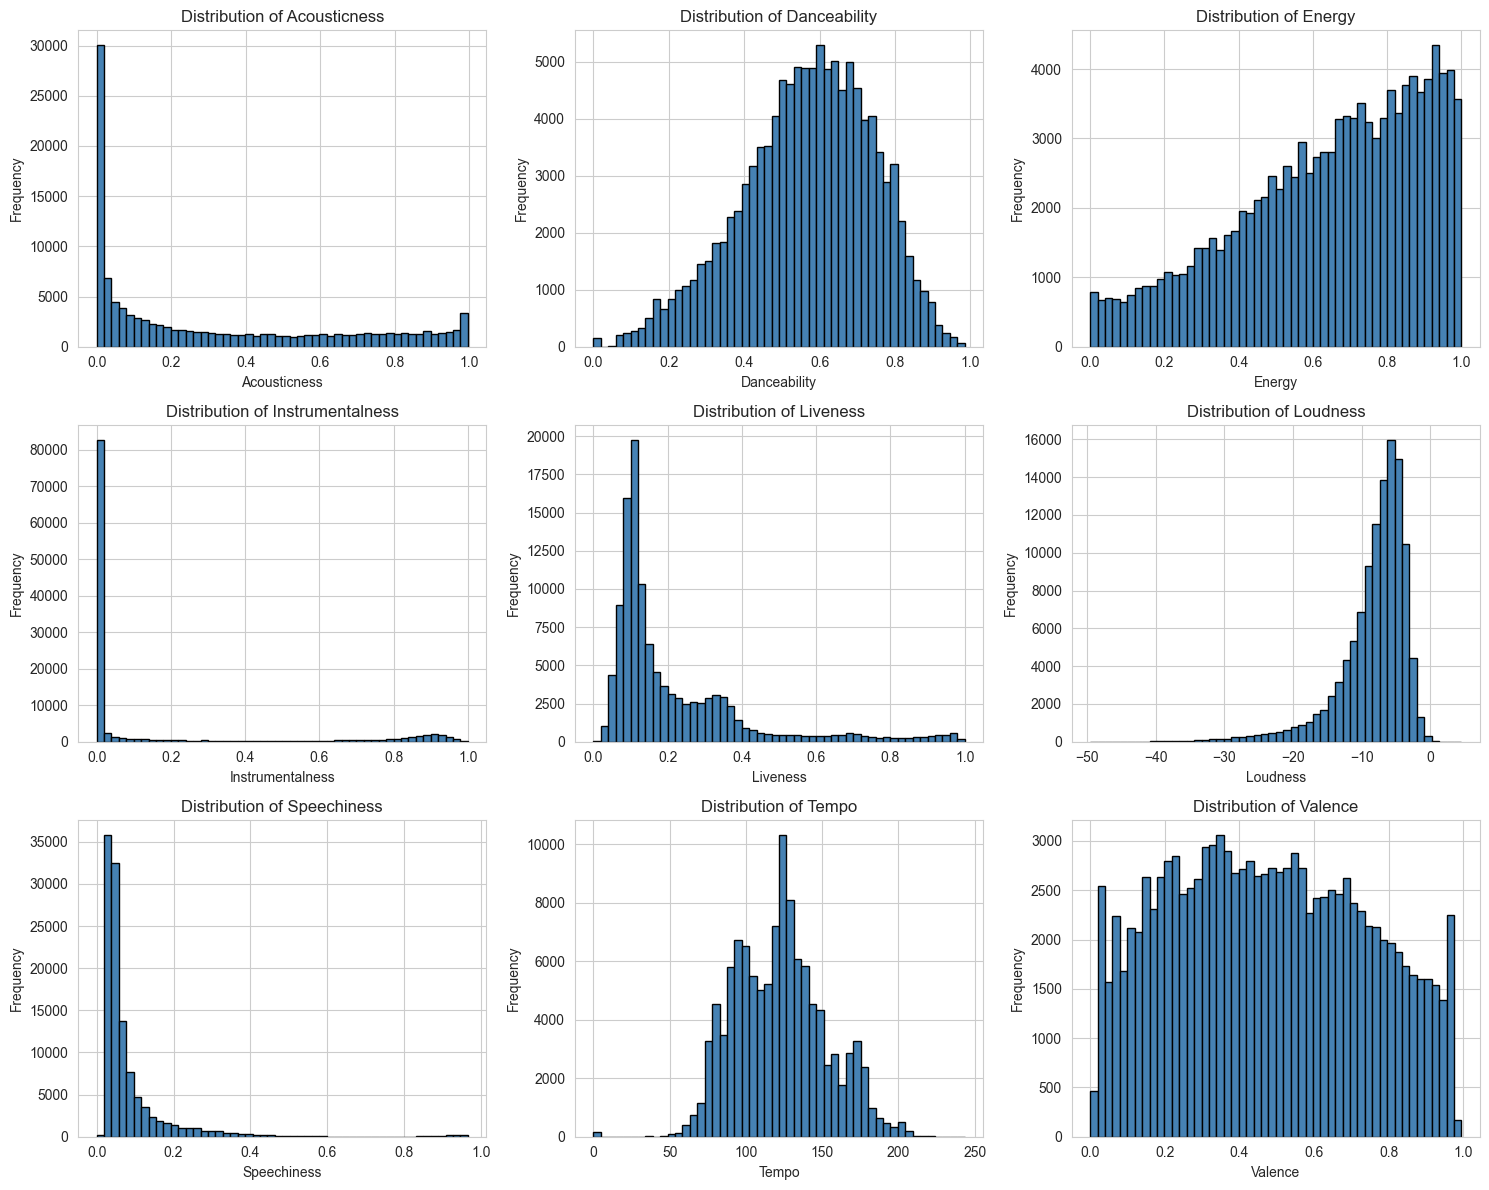

In [ ]:
# Gráficos de distribución de características de audio
audio_features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 
                   'liveness', 'loudness', 'speechiness', 'tempo', 'valence']

available_features = [col for col in audio_features if col in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(available_features[:9]):
    axes[idx].hist(df[feature].dropna(), bins=50, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'Distribución de {feature.title()}')
    axes[idx].set_xlabel(feature.title())
    axes[idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 2.2. Análisis de popularidad

Examinemos cómo se distribuye la popularidad de las pistas en el dataset.

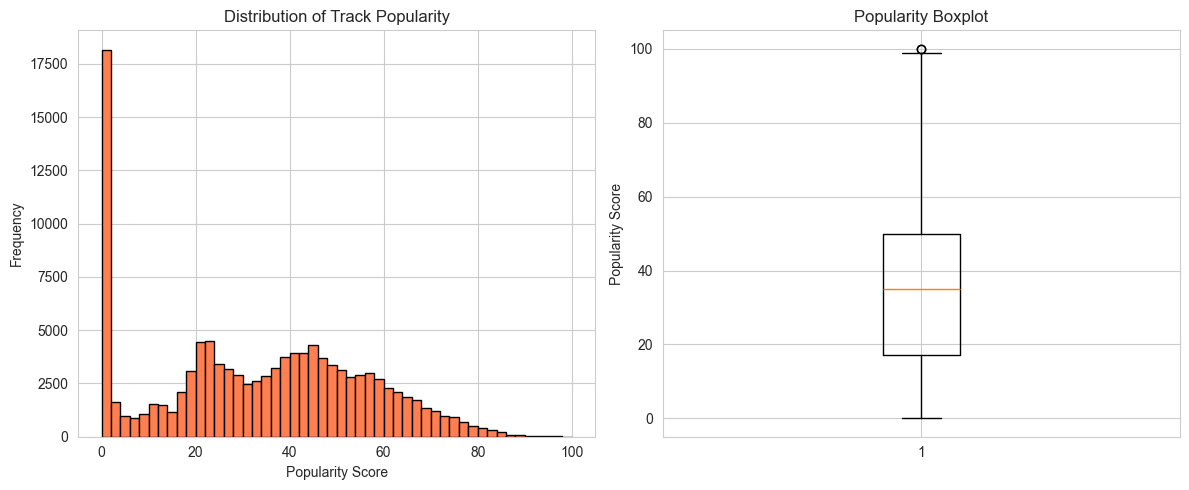


Popularity Statistics:
count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64


In [ ]:
if 'popularity' in df.columns:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(df['popularity'].dropna(), bins=50, color='coral', edgecolor='black')
    plt.title('Distribución de Popularidad de Pistas')
    plt.xlabel('Puntuación de Popularidad')
    plt.ylabel('Frecuencia')
    
    plt.subplot(1, 2, 2)
    plt.boxplot(df['popularity'].dropna())
    plt.title('Gráfico de Caja de Popularidad')
    plt.ylabel('Puntuación de Popularidad')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nEstadísticas de Popularidad:")
    print(df['popularity'].describe())

## 2.3. Correlaciones entre características de audio

Examinamos cómo diferentes características de audio se relacionan entre sí y con la popularidad.

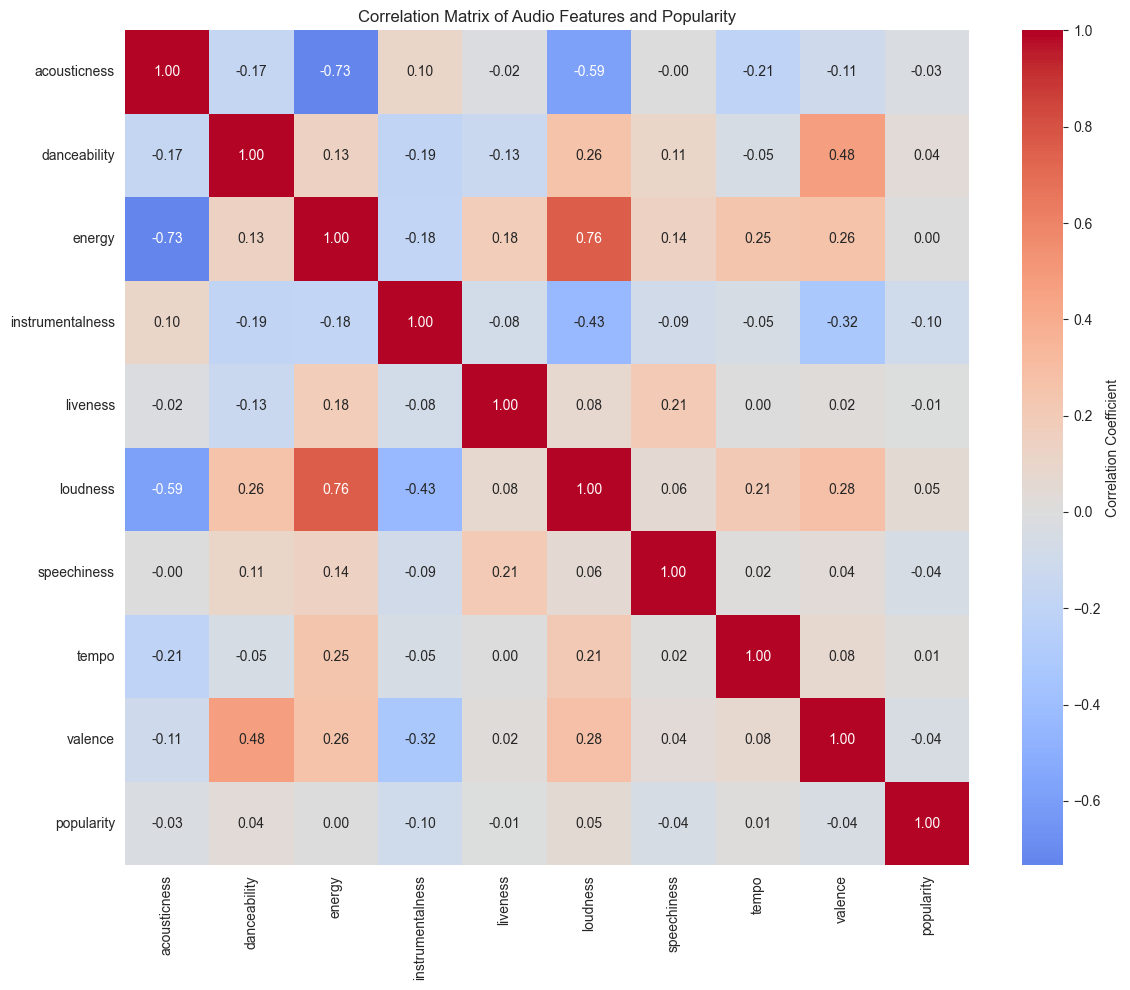

In [ ]:
# Seleccionar características de audio para análisis de correlación
correlation_cols = [col for col in available_features if col in df.columns]
if 'popularity' in df.columns:
    correlation_cols.append('popularity')

# Calcular matriz de correlación
if len(correlation_cols) > 1:
    correlation_matrix = df[correlation_cols].corr()
    
    # Gráfico de mapa de calor de correlación
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                cbar_kws={'label': 'Coeficiente de Correlación'})
    plt.title('Matriz de Correlación de Características de Audio y Popularidad')
    plt.tight_layout()
    plt.show()

## 2.4. Relación entre características de audio y popularidad

Analizamos cómo características de audio individuales se relacionan con la popularidad de las pistas.

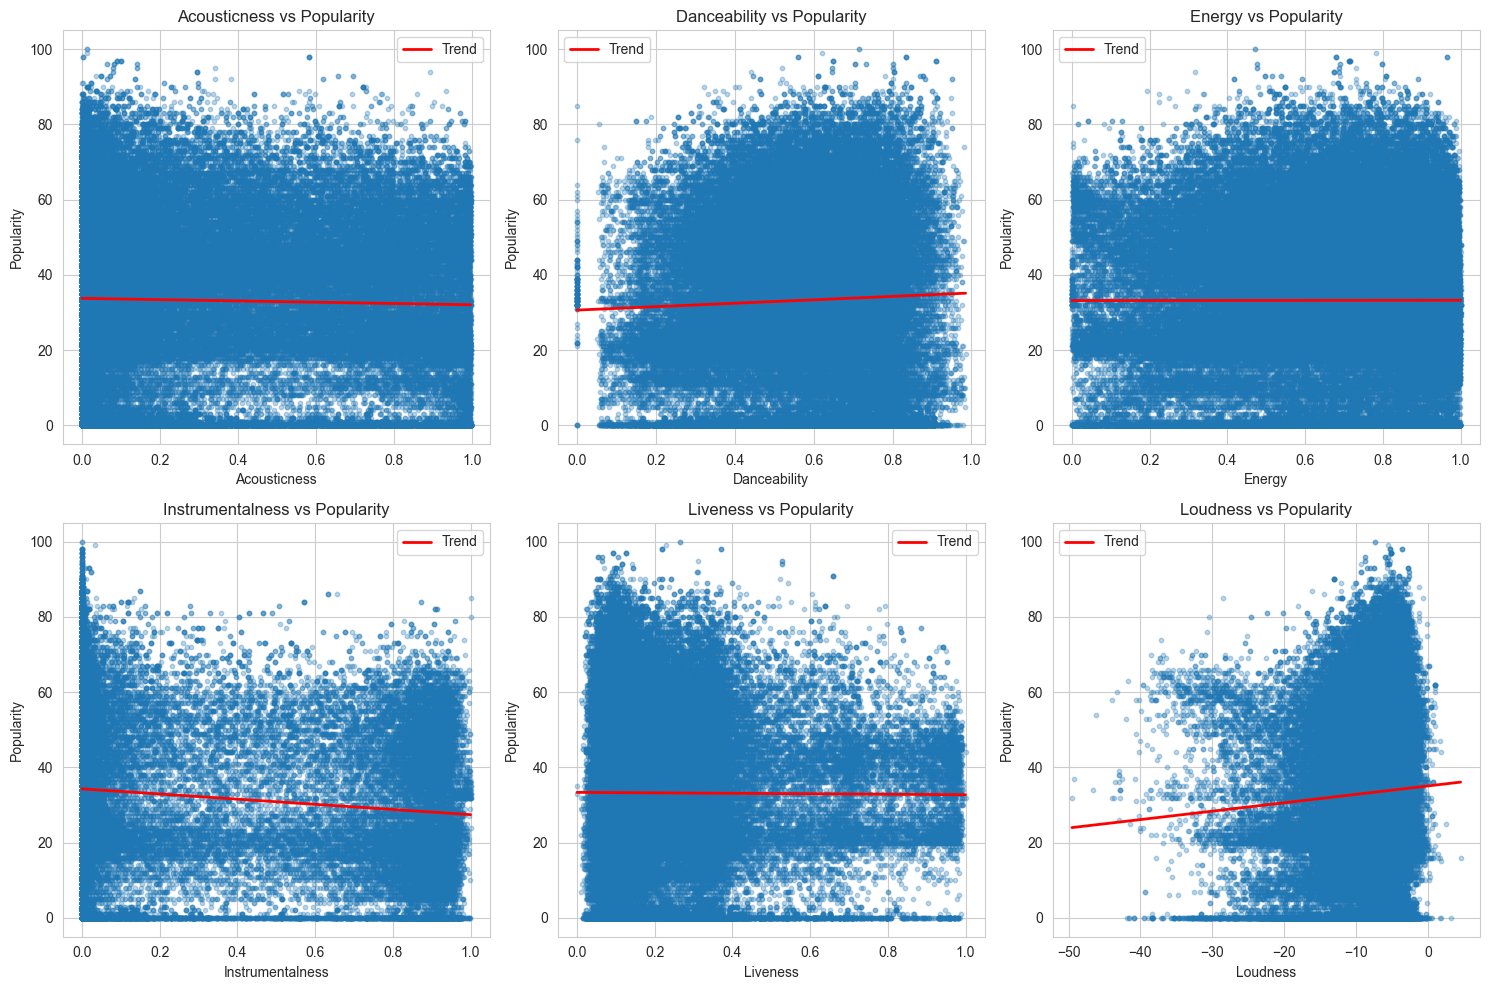

In [ ]:
if 'popularity' in df.columns and len(available_features) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    features_to_plot = available_features[:6]
    
    for idx, feature in enumerate(features_to_plot):
        axes[idx].scatter(df[feature], df['popularity'], alpha=0.3, s=10)
        axes[idx].set_xlabel(feature.title())
        axes[idx].set_ylabel('Popularidad')
        axes[idx].set_title(f'{feature.title()} vs Popularidad')
        
        # Agregar línea de tendencia
        z = np.polyfit(df[feature].dropna(), df.loc[df[feature].notna(), 'popularity'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
        axes[idx].plot(x_line, p(x_line), 'r-', linewidth=2, label='Tendencia')
        axes[idx].legend()
    
    plt.tight_layout()
    plt.show()

---

# 3. Insights clave y conclusiones

## Resumen de hallazgos

Basado en el análisis exploratorio, podemos derivar varios insights sobre el dataset de pistas de Spotify:

1. **Distribución de características de audio**: diferentes características de audio muestran distribuciones variadas, indicando diversidad en el catálogo musical.

2. **Patrones de popularidad**: la popularidad de las pistas varía significativamente, sugiriendo diferentes preferencias y patrones de engagement de la audiencia.

3. **Relaciones entre características**: ciertas características de audio muestran correlación con la popularidad, lo que podría ser útil para entender qué hace que una pista sea exitosa.

4. **Diversidad musical**: el dataset refleja la diversidad de la música en Spotify, desde pistas acústicas e instrumentales hasta contenido de alta energía y con mucho habla.

Estos insights pueden informar estrategias de producción musical, curación y recomendación.